# Analysis
This notebook contains all the math and thinking that went behind designing this particular filter

## Imports and Equations

In [1]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
time_secs = 30

Depth Series

In [3]:
tdepth = np.arange(0,time_secs,0.1) # 60 seconds, 10 Hz
depth = 5 + 2 * np.sin(0.2 * tdepth)

IMU series

In [4]:
timu = np.arange(0,time_secs,0.01) # 60 seconds, 100 Hz cos IMUs are faster
dz = 0.4 * np.cos(0.2 * timu)
ddz = -0.08 * np.sin(0.2 * timu)
v = 1.0
g = 9.81

#pitch
theta = np.arctan2(dz,v)
# pitch rate
theta_dot = (-0.08 * np.sin(0.2 * timu) * v) / (v**2 + dz**2)

# orientation - xyzw quaternion
orientation = np.zeros((timu.shape[0],4))
orientation[:,1] = np.sin(theta/2)
orientation[:,3] = np.cos(theta/2)

# Linear Accel - xyz
lin_acc = np.zeros((timu.shape[0],3))
lin_acc[:,0] = -g * np.sin(theta)
lin_acc[:,2] = ddz + g * np.cos(theta)

# we don't care about angular vel just yet

## Adding Noise

In [5]:
depth_stddev = 0.1
imu_stddev = 0.1 # I'm lazy, having the same general gaussian error for all imu measurements

noisy_depth = depth + np.random.normal(0, depth_stddev, depth.shape[0])

noisy_theta = np.arctan2(dz,v) + np.random.normal(0, imu_stddev, theta.shape[0])
gyro_noise = np.random.normal(0, imu_stddev, theta_dot.shape[0])
noisy_theta_dot = theta_dot + gyro_noise

acc_noise = np.random.normal(0, imu_stddev, lin_acc.shape)
noisy_lin_acc = lin_acc + acc_noise

## Velocity

In [6]:
depth_sensor_vel = 0.4 * np.cos(0.2 * tdepth)
noisy_depth_sensor_vel = depth_sensor_vel + np.random.normal(0, depth_stddev, depth_sensor_vel.shape[0])

In [7]:
imu_acc_world = np.zeros_like(lin_acc)
noisy_imu_acc_world = np.zeros_like(lin_acc)
imu_vel_world = np.zeros_like(lin_acc)
noisy_imu_vel_world = np.zeros_like(lin_acc)

dt = 0.01
vel = np.zeros(3)

for i in range(len(timu)):
    r = R.from_quat(orientation[i])

    # rotate to world frame
    acc_world = r.apply(lin_acc[i])

    # remove gravity (assuming Z-up world)
    acc_world[2] -= 9.81

    imu_acc_world[i] = acc_world

    # integrate to velocity
    vel += acc_world * dt
    imu_vel_world[i] = vel

vel = np.zeros(3)
for i in range(len(timu)):
    r = R.from_quat(orientation[i])

    # rotate to world frame
    noisy_acc_world = r.apply(noisy_lin_acc[i])

    # remove gravity (assuming Z-up world)
    noisy_acc_world[2] -= 9.81

    noisy_imu_acc_world[i] = noisy_acc_world

    # integrate to velocity
    vel += noisy_acc_world * dt
    noisy_imu_vel_world[i] = vel

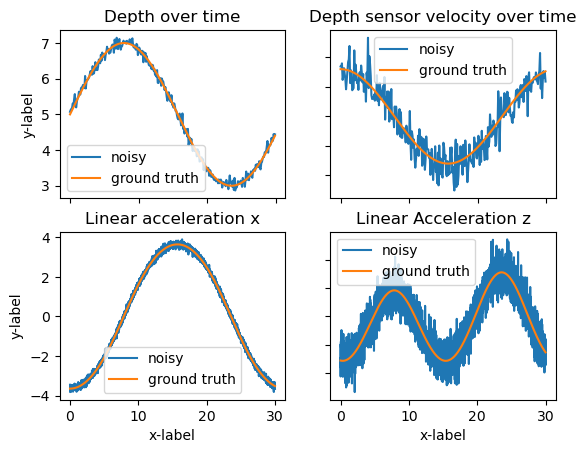

In [8]:
fig, axs = plt.subplots(2, 2)
axs[0, 0].plot(tdepth, noisy_depth, label='noisy')
axs[0, 0].plot(tdepth, depth, label='ground truth')
axs[0, 0].set_title('Depth over time')
axs[0, 1].plot(tdepth, noisy_depth_sensor_vel, label='noisy')
axs[0, 1].plot(tdepth, depth_sensor_vel, label='ground truth')
axs[0, 1].set_title('Depth sensor velocity over time')
axs[1, 0].plot(timu, noisy_lin_acc[:,0], label='noisy')
axs[1, 0].plot(timu, lin_acc[:,0], label='ground truth')
axs[1, 0].set_title('Linear acceleration x')
axs[1, 1].plot(timu, noisy_lin_acc[:,2], label='noisy')
axs[1, 1].plot(timu, lin_acc[:,2], label='ground truth')
axs[1, 1].set_title('Linear Acceleration z')

for ax in axs.flat:
    ax.set(xlabel='x-label', ylabel='y-label')
    ax.legend()

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

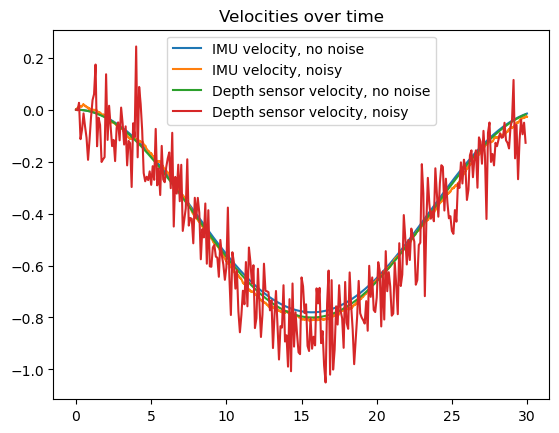

In [9]:
# align to remove integration constants
imu_vel_world -= imu_vel_world[0]
noisy_imu_vel_world -= noisy_imu_vel_world[0]
depth_sensor_vel -= depth_sensor_vel[0]
noisy_depth_sensor_vel -= noisy_depth_sensor_vel[0]

plt.title('Velocities over time')
plt.plot(timu, imu_vel_world[:,-1], label='IMU velocity, no noise')
plt.plot(timu, noisy_imu_vel_world[:,-1], label='IMU velocity, noisy')
plt.plot(tdepth, depth_sensor_vel, label='Depth sensor velocity, no noise')
plt.plot(tdepth, noisy_depth_sensor_vel, label='Depth sensor velocity, noisy')
plt.legend()
plt.show()

Depth sensor velocity is noisy. a high pass filter should help here. 

## Kalman Filter

In [10]:
class KalmanFilter:
    def __init__(self, F = None, B = None, H = None, Q = None, R = None, P = None, x0 = None):
        self.n = F.shape[1]
        self.m = H.shape[1]

        self.F = F
        self.H = H
        self.B = 0 if B is None else B
        self.Q = np.eye(self.n) if Q is None else Q
        self.R = np.eye(self.m) if R is None else R
        self.P = np.eye(self.n) if P is None else P
        self.x = np.zeros((self.n, 1)) if x0 is None else x0

    def _prediction_step(self, u = 0):
        self.x = np.dot(self.F,self.x) + np.dot(self.B,u) 
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x

    def _update_step(self, z):
        y = z - np.dot(self.H, self.x)
        S = self.R + np.dot(self.H, np.dot(self.P, self.H.T))
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.n)
        self.P = np.dot(np.dot(I - np.dot(K, self.H), self.P), 
        	(I - np.dot(K, self.H)).T) + np.dot(np.dot(K, self.R), K.T)

### Tuning Params

In [ ]:
dt = 0.1

F = np.array([[1, dt],
            [0, 1]])

B = np.array([[0.5 * dt**2],
            [dt]])

H = np.array([[1, 0],
              [0, 1]])

Q = np.array([[0.01, 0],
            [0, 0.1]])   # tune later

R = np.array([[10, 0],
              [0,  100]])

P = np.eye(2)

x0 = np.zeros((2, 1))

kalman = KalmanFilter(F, B, H, Q, R, P, x0)

### Run loop

In [27]:
kalman_filter_velocity = np.zeros_like(depth_sensor_vel)

for i in range(len(tdepth)-1):
    # kalman._prediction_step(u=noisy_imu_vel_world[i*10,-1])
    kalman._prediction_step(u=noisy_imu_acc_world[i*10, -1])
    # kalman._update_step(np.array([[noisy_depth[i]]]))
    z = np.array([[noisy_depth[i]],
              [noisy_depth_sensor_vel[i]]])
    kalman._update_step(z)
    kalman_filter_velocity[i] = float(kalman.x[1][0])

# kalman_filter_velocity = np.diff(kalman_filter_depth)
# kalman_filter_velocity = np.append(kalman_filter_velocity,0.0)

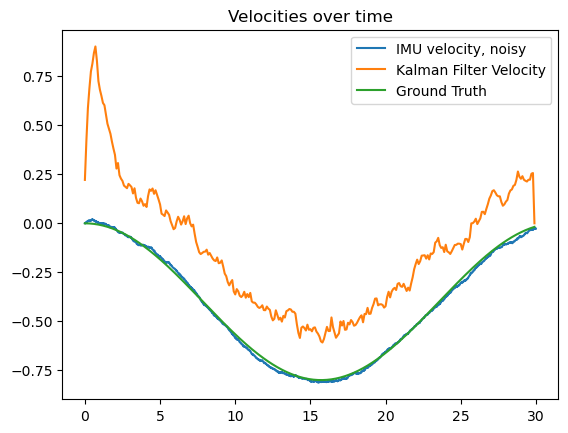

In [28]:
# align to remove integration constants
imu_vel_world -= imu_vel_world[0]
noisy_imu_vel_world -= noisy_imu_vel_world[0]
depth_sensor_vel -= depth_sensor_vel[0]
noisy_depth_sensor_vel -= noisy_depth_sensor_vel[0]

plt.title('Velocities over time')
plt.plot(timu, noisy_imu_vel_world[:,-1], label='IMU velocity, noisy')
# plt.plot(tdepth, noisy_depth_sensor_vel, label='Depth sensor velocity, noisy')
plt.plot(tdepth, kalman_filter_velocity, label='Kalman Filter Velocity')
plt.plot(tdepth, depth_sensor_vel, label='Ground Truth')
plt.legend()
plt.show()